# U(1) Symmetry in MPS Classification (Phase 0 + Phase 1 + Phase 2 scaffold)

**Phase 0** — dense MPS + flux masking.  
**Phase 1** — sector-aligned label site + gradient projection (`u1_block_mode=true`).  
**Phase 2** (experimental) — full-chain bond layout + `u1_path_block_mode=true`.

| Section | Content |
|---------|---------|
| §3 | Baseline A–C on **drift** data |
| §4 | Path-charge diagnostics |
| §7 | **Pareto** sweep (`u1_soft_strength`, 3 seeds) |
| §8 | Datasets: drift, **`:flux_exact`**, `:flux_nearest`, `:neutral` |
| §9 | **Symmetry audit** — do SVD/Adam break U(1)? |
| §10 | **C3** bounded data-matched charges |
| §11 | **C4** empirical label-bond `Q` range |
| §12 | **Phase 1 block mode** — C4 dense vs block-sparse label |
| §13 | **Phase 1 ablations** — fair compare, capacity, init, traces |
| §14 | **P1 polish** — multi-seed, soft→hard, compat gate |

**Phase 0 hard**: zero forbidden blocks (per bond for `u1_label_spec`; **once per epoch** for
path specs with `sites=:label_only`).  
**Phase 0 soft**: multiply forbidden blocks by `(1 - strength)`.  
**Phase 1**: project merged-bond gradients at `j = Ml-1`; label projection at epoch end (no masking massacre).  
**`:soft_then_hard`**: soft for `u1_soft_epochs`, then hard (dense mask or block projection).

Symmetry is on the **TN ansatz**, not on the data.

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using Random, Statistics, Printf
using Plots

# Jupyter keeps stale `train_mps!` in Main after src edits. Re-include training.jl
# from disk on every §1 run, then re-bind exported call sites in Main.
function refresh_mpsfast_training!()
    pkg = pkgdir(MPSFast)
    src = joinpath(pkg, "src")
    for f in ("symmetry.jl", "u1_block_sparse.jl", "u1_path_block.jl", "training.jl")
        Base.include(MPSFast, joinpath(src, f))
    end
    global train_mps! = MPSFast.train_mps!
    global cosine_lr = MPSFast.cosine_lr
    return train_mps!
end

function _train_mps_has_epoch_callback(f = MPSFast.train_mps!)
    mps = init_mps_classification(4, 2, 2, 4; rng = MersenneTwister(0))
    xi = ones(Int64, 1, 4)
    try
        f(mps, xi, 0, 0.01, 4, 1e-10; epoch_callback = nothing, verbose = false)
        return true
    catch err
        err isa MethodError || return true
        return !occursin("epoch_callback", sprint(show, err))
    end
end

function ensure_train_mps_epoch_callback!()
    _train_mps_has_epoch_callback() || refresh_mpsfast_training!()
    _train_mps_has_epoch_callback() ||
        error("train_mps! still lacks epoch_callback; restart kernel and re-run §1–§2.")
end

refresh_mpsfast_training!()
@assert _train_mps_has_epoch_callback() "train_mps! missing epoch_callback after refresh"

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
┌ Warning: Replacing docs for `MPSFast.SymmetryMode :: Union{}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.U1Spec :: Union{}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.NoSymmetry :: Union{}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.symmetry_active :: Tuple{U1Spec}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.u1_label_spec :: Tuple{Int64}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.u1_path_centered_spec :: Tuple{Int64, Int64}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast.bounded_q_label :: Tuple{Real}` in module `MPSFast`
└ @ Base.Docs docs/Docs.jl:249
┌ Warning: Replacing docs for `MPSFast._bond_index_charges 

## 1. Shared dataset

In [2]:
function synthetic_paths_labels(N, M; drift=0.15, σ=1.0, rng=Random.default_rng())
    paths  = Matrix{Float64}(undef, N, M)
    labels = Vector{Int}(undef, N)
    for i in 1:N
        y = rand(rng, 1:2)
        d = y == 1 ? drift : -drift
        paths[i, :] = cumsum(d .+ σ .* randn(rng, M))
        labels[i]   = y
    end
    return paths, labels
end

function random_walk_paths(N, M; drift=0.0, σ=1.0, rng=Random.default_rng())
    paths = Matrix{Float64}(undef, N, M)
    for i in 1:N
        paths[i, :] = cumsum(drift .+ σ .* randn(rng, M))
    end
    return paths
end

"""Resample neutral walks until `N` paths have exact flux closure under `spec`.

`enc` must already be fitted; do not refit here (train/test share one grid)."""
function collect_flux_exact(N, M, enc, spec, n_classes; rng=Random.default_rng(), batch=400)
    paths_buf = Vector{Vector{Float64}}()
    labels_buf = Int[]
    while length(labels_buf) < N
        batch_paths = random_walk_paths(batch, M; rng=rng)
        xi = encode_paths(enc, batch_paths)
        for i in 1:batch
            c = flux_exact_class(xi[i, :], spec, n_classes)
            c == 0 && continue
            push!(paths_buf, copy(batch_paths[i, :]))
            push!(labels_buf, c)
            length(labels_buf) >= N && break
        end
    end
    paths = Matrix{Float64}(undef, N, M)
    for i in 1:N
        paths[i, :] = paths_buf[i]
    end
    return paths, labels_buf[1:N]
end

"""Build train/test bundles for drift, flux-aligned, flux-exact, or neutral control data."""
function make_dataset(kind::Symbol;
    N_train=2_000, N_test=500, M=15, n_classes=2,
    rng=Random.default_rng(), encoder_bins=3,
)
    enc = BasisEncoder(encoder_bins)
    if kind == :drift
        train_paths, train_labels = synthetic_paths_labels(N_train, M; rng=rng)
        test_paths,  test_labels  = synthetic_paths_labels(N_test,  M; rng=rng)
    elseif kind == :flux_nearest
        train_paths = random_walk_paths(N_train, M; drift=0.0, rng=rng)
        test_paths  = random_walk_paths(N_test,  M; drift=0.0, rng=rng)
        fit_grid!(enc, train_paths)
        d = site_dim(enc)
        probe = u1_path_centered_spec(d, n_classes)
        xi_tr = encode_paths(enc, train_paths)
        xi_te = encode_paths(enc, test_paths)
        train_labels = [flux_nearest_class(xi_tr[i, :], probe, n_classes) for i in 1:N_train]
        test_labels  = [flux_nearest_class(xi_te[i, :], probe, n_classes) for i in 1:N_test]
    elseif kind == :flux_exact
        warm = random_walk_paths(800, M; rng=rng)
        fit_grid!(enc, warm)
        d = site_dim(enc)
        probe = u1_path_centered_spec(d, n_classes)
        train_paths, train_labels = collect_flux_exact(N_train, M, enc, probe, n_classes; rng=rng)
        test_paths,  test_labels  = collect_flux_exact(N_test,  M, enc, probe, n_classes; rng=rng)
    elseif kind == :neutral
        train_paths = random_walk_paths(N_train, M; drift=0.0, rng=rng)
        test_paths  = random_walk_paths(N_test,  M; drift=0.0, rng=rng)
        train_labels = rand(rng, 1:n_classes, N_train)
        test_labels  = rand(rng, 1:n_classes, N_test)
    else
        error("unknown dataset kind = $kind  (use :drift, :flux_nearest, :flux_exact, :neutral)")
    end
    kind in (:flux_nearest, :flux_exact) || fit_grid!(enc, train_paths)
    xi_train = encode_labeled_paths(enc, train_paths, train_labels; n_classes=n_classes)
    xi_test  = encode_labeled_paths(enc, test_paths,  test_labels;  n_classes=n_classes)
    Ml = classification_chain_length(enc, M)
    d  = site_dim(enc)
    if kind == :flux_exact
        probe = u1_path_centered_spec(d, n_classes)
        rate = sector_compatibility_rate(xi_train, probe)
        rate > 0.99 || @warn "flux_exact train compat=$rate (expected ≈1); re-run §1"
    end
    return (; kind, enc, train_paths, train_labels, test_paths, test_labels,
            xi_train, xi_test, Ml, d, n_classes)
end

rng = MersenneTwister(42)
data_drift = make_dataset(:drift; rng=rng)

# §3–§6 default: drift dataset
xi_train, xi_test = data_drift.xi_train, data_drift.xi_test
Ml_class, d_class = data_drift.Ml, data_drift.d
n_classes = data_drift.n_classes
train_labels, test_labels = data_drift.train_labels, data_drift.test_labels

D_max, η, ε_cut = 32, 5e-4, 1e-5
D_max_phase1 = 64   # Phase 1 block needs wider bonds (§12–§14)
n_epochs, patience = 50, 8
u1_soft_epochs = 10   # for :soft_then_hard
compat_threshold = 0.5 # u1_training_plan / compat_gate cutoff

println("dataset=:drift  train=", size(xi_train), "  test=", size(xi_test))
println("Ml=", Ml_class, "  d_path=", d_class)

dataset=:drift  train=(2000, 16)  test=(500, 16)
Ml=16  d_path=8


## 2. Training helper

In [3]:
function _u1_forbid_ratio(mps, spec, nc, d; use_block::Bool)
    if use_block
        layout = build_u1_label_layout(spec, mps, nc, d)
        _, _, r = u1_block_forbidden_mass(mps, layout)
        return r
    end
    _, _, r = u1_forbidden_mass(mps, spec; n_classes=nc, d_path=d)
    return r
end

function run_u1_experiment(;
    name::String,
    spec::U1Spec,
    conservation::Symbol,
    soft_strength::Float64 = 0.9,
    seed::Int = 1,
    data = data_drift,
    epochs::Int = n_epochs,
    u1_block_mode::Bool = false,
    u1_path_block_mode::Bool = false,
    D_max_train::Int = D_max,
    block_sector_align::Bool = true,
    trace_epochs::Bool = false,
    compat_gate::Bool = false,
    compat_threshold::Float64 = compat_threshold,
    auto_block_D::Bool = true,
    u1_soft_epochs_kw::Int = -1,
)
    xi_tr, xi_te = data.xi_train, data.xi_test
    Ml, d = data.Ml, data.d
    nc = data.n_classes

    init_rng = MersenneTwister(seed)
    layout = nothing
    block = nothing
    use_block = u1_block_mode && u1_use_block_mode(spec, true)
    plan_reason = "manual"
    spec_eff = spec
    conservation_eff = conservation

    if compat_gate && spec !== NoSymmetry
        plan = u1_training_plan(xi_tr, spec;
            compat_threshold = compat_threshold,
            D_max_dense = D_max, D_max_block = D_max_phase1,
            conservation = conservation)
        if !plan.use_symmetry
            spec_eff = NoSymmetry
            use_block = false
            conservation_eff = :none
            plan_reason = plan.reason
        else
            use_block = plan.use_block
            conservation_eff = plan.conservation
            D_max_train = plan.D_max_train
            plan_reason = plan.reason
        end
    elseif auto_block_D && use_block && D_max_train <= D_max
        D_max_train = D_max_phase1
    end

    soft_epochs_train = conservation_eff == :soft_then_hard ?
        (u1_soft_epochs_kw > 0 ? u1_soft_epochs_kw : u1_soft_epochs) : 0

    if spec_eff === NoSymmetry
        mps = init_mps_classification(Ml, d, nc, D_max_train; rng=init_rng)
        allowed_frac = 1.0
    elseif use_block
        mps, layout, block = init_mps_classification_u1_block(
            Ml, d, nc, D_max_train, spec_eff; rng=init_rng, sector_align=block_sector_align)
        allowed_frac = u1_block_label_stats(mps, layout, block).allowed_fraction
    else
        mps = init_mps_classification_u1(Ml, d, nc, D_max_train, spec_eff; rng=init_rng)
        allowed_frac = u1_allowed_fraction(mps, spec_eff; n_classes=nc, d_path=d)
    end

    val_log = Float64[]
    test_trace = Float64[]
    forbid_trace = Float64[]

    train_kw = (
        verbose = false,
        lr_schedule = cosine_lr,
        val_data = xi_te,
        val_samples = 500,
        patience = patience,
        val_nll_log = val_log,
        u1_spec = spec_eff,
        u1_conservation = conservation_eff,
        u1_soft_strength = soft_strength,
        u1_soft_epochs = soft_epochs_train,
        n_classes = nc,
        d_path = d,
        u1_block_mode = use_block,
        u1_path_block_mode = u1_path_block_mode,
    )

    if trace_epochs
        ensure_train_mps_epoch_callback!()
        epoch_cb = function (mps, _ep, _stats)
            push!(test_trace, classification_accuracy(mps, xi_te, nc))
            push!(forbid_trace, _u1_forbid_ratio(mps, spec_eff, nc, d; use_block))
        end
        nll_hist = MPSFast.train_mps!(mps, xi_tr, epochs, η, D_max_train, ε_cut;
            train_kw..., epoch_callback = epoch_cb)
    else
        nll_hist = MPSFast.train_mps!(mps, xi_tr, epochs, η, D_max_train, ε_cut; train_kw...)
    end

    train_acc = classification_accuracy(mps, xi_tr, nc)
    test_acc  = classification_accuracy(mps, xi_te,  nc)
    compat_tr = sector_compatibility_rate(xi_tr, spec_eff)
    compat_te = sector_compatibility_rate(xi_te,  spec_eff)

    if use_block
        layout = build_u1_label_layout(spec_eff, mps, nc, d)
        block = extract_u1_block_label(mps[end], layout)
        _, _, forbid_ratio = u1_block_forbidden_mass(mps, layout)
        block_stats = u1_block_label_stats(mps, layout, block)
    else
        _, _, forbid_ratio = u1_forbidden_mass(mps, spec_eff; n_classes=nc, d_path=d)
        block_stats = nothing
    end

    return (; name, spec=spec_eff, conservation=conservation_eff, soft_strength,
            data_kind=data.kind, mps, nll_hist, val_log, allowed_frac, forbid_ratio,
            train_acc, test_acc, compat_tr, compat_te,
            u1_block_mode=use_block, u1_path_block_mode, block_stats, D_max_train,
            block_sector_align, test_trace, forbid_trace, plan_reason)
end

"""Pad C4 `label_left_range` by `pad` charges on each side."""
function widen_c4_spec(spec::U1Spec; pad::Int=2)
    spec.label_left_range === nothing && return spec
    ql, qr = spec.label_left_range
    return U1Spec(spec.mode, spec.q_path, spec.q_label, spec.sites, (ql - pad, qr + pad))
end

function print_ablation_row(r)
    compact = r.block_stats === nothing ? 1.0 :
        r.block_stats.compact_params / r.block_stats.dense_params
    @printf "%-32s %6.1f%% %10.3f %10.4f %10.3f %4d\n" r.name 100r.test_acc r.compat_tr r.forbid_ratio compact r.D_max_train
end

print_ablation_row (generic function with 1 method)

## 3. Experiments A–C

**Restart the kernel** after pulling MPSFast changes so `u1_path_centered_spec` picks up
`sites=:label_only` and epoch-end masking.

| Symptom (old runs) | Cause |
|--------------------|-------|
| `allowed_frac ≈ 0.03`, C finishes in &lt;1 s | `sites=:all` masked the whole chain |
| `NaN/Inf gradient` + `‖mps[1]‖ = 0` | per-bond hard mask on label site after bond 15 destroyed the tensor |

With the fix, C1/C2 should run ~10 s like B1/B2, `allowed_frac ≈ 1.0` (path sites dominate),
and `compat(train)` stays low (~0.1) because most labels violate strict flux closure.

In [4]:
configs = [
    (; name="A baseline",           spec=NoSymmetry,              conservation=:none, soft=0.0),
    (; name="B1 U1 label hard",     spec=u1_label_spec(n_classes), conservation=:hard, soft=0.0),
    (; name="B2 U1 label soft",     spec=u1_label_spec(n_classes), conservation=:soft, soft=0.9),
    (; name="C1 U1 path hard",      spec=u1_path_centered_spec(d_class, n_classes), conservation=:hard, soft=0.0),
    (; name="C2 U1 path soft",      spec=u1_path_centered_spec(d_class, n_classes), conservation=:soft, soft=0.9),
]

results = Vector{Any}(undef, length(configs))
for (k, cfg) in enumerate(configs)
    println("\n=== ", cfg.name, " ===")
    @time results[k] = run_u1_experiment(;
        name = cfg.name,
        spec = cfg.spec,
        conservation = cfg.conservation,
        soft_strength = cfg.soft,
        seed = 1,
    )
    r = results[k]
    @printf "  allowed_frac=%.3f  train=%.1f%%  test=%.1f%%  compat(train)=%.3f\n" r.allowed_frac 100r.train_acc 100r.test_acc r.compat_tr
end


=== A baseline ===
  7.570898 seconds (28.91 M allocations: 9.704 GiB, 9.03% gc time, 31.74% compilation time)
  allowed_frac=1.000  train=75.2%  test=65.0%  compat(train)=1.000

=== B1 U1 label hard ===
 12.086095 seconds (8.44 M allocations: 8.644 GiB, 5.07% gc time, 1.15% compilation time)
  allowed_frac=1.000  train=70.0%  test=54.6%  compat(train)=0.486

=== B2 U1 label soft ===
 13.360641 seconds (8.04 M allocations: 8.627 GiB, 5.32% gc time)
  allowed_frac=1.000  train=61.5%  test=45.4%  compat(train)=0.486

=== C1 U1 path hard ===
  4.311863 seconds (3.34 M allocations: 5.540 GiB, 10.03% gc time, 0.38% compilation time)
  allowed_frac=0.999  train=45.4%  test=43.0%  compat(train)=0.095

=== C2 U1 path soft ===
  5.328660 seconds (4.97 M allocations: 8.364 GiB, 9.17% gc time)
  allowed_frac=0.999  train=51.4%  test=48.2%  compat(train)=0.095


## 4. Diagnostics — conserved quantity in data space?

For `u1_path_centered_spec`, path charge is `Q(x) = Σ_t (σ_t − center)`.
If classes differ in drift, `Q(x)` may separate labels even though symmetry is **model-side**.

Mean Q(x) by class (train): [2.013374485596708, -5.663424124513619]
Flux compatibility (path spec, train): 0.095
Flux compatibility (label spec, train): 0.486


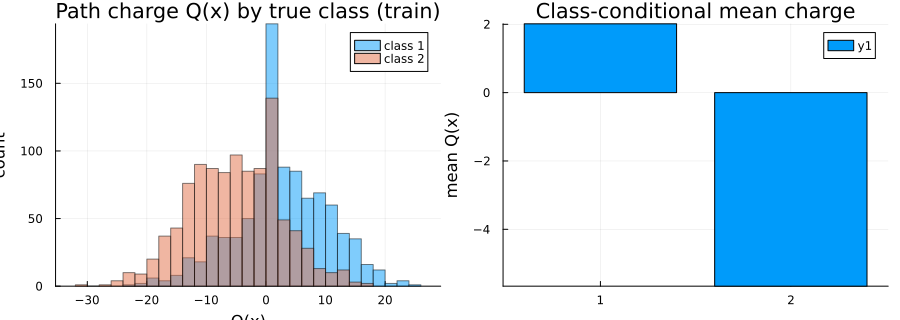

In [5]:
spec_path = u1_path_centered_spec(d_class, n_classes)
spec_lbl  = u1_label_spec(n_classes)
train_labels = data_drift.train_labels

Q_train = [path_total_charge(xi_train[i, 1:end-1], spec_path) for i in 1:size(xi_train, 1)]
Q_test  = [path_total_charge(xi_test[i, 1:end-1],  spec_path) for i in 1:size(xi_test, 1)]

mean_Q = mean_path_charge_by_class(xi_train, spec_path, n_classes)
println("Mean Q(x) by class (train): ", mean_Q)
println("Flux compatibility (path spec, train): ", sector_compatibility_rate(xi_train, spec_path))
println("Flux compatibility (label spec, train): ", sector_compatibility_rate(xi_train, spec_lbl))

p1 = histogram(Q_train[train_labels .== 1], bins=30, alpha=0.5, label="class 1")
histogram!(p1, Q_train[train_labels .== 2], bins=30, alpha=0.5, label="class 2")
title!(p1, "Path charge Q(x) by true class (train)")
xlabel!(p1, "Q(x)"); ylabel!(p1, "count")

p2 = bar(string.(1:n_classes), mean_Q, ylabel="mean Q(x)", title="Class-conditional mean charge")
plot(p1, p2, layout=(1, 2), size=(900, 320))

## 5. Summary table & learning curves

%-22s %8s %8s %8s %10s %10snameallowedtrain%test%compat_trcompat_te
A baseline                1.000    75.2%    65.0%      1.000      1.000
B1 U1 label hard          1.000    70.0%    54.6%      0.486      0.518
B2 U1 label soft          1.000    61.5%    45.4%      0.486      0.518
C1 U1 path hard           0.999    45.4%    43.0%      0.095      0.124
C2 U1 path soft           0.999    51.4%    48.2%      0.095      0.124


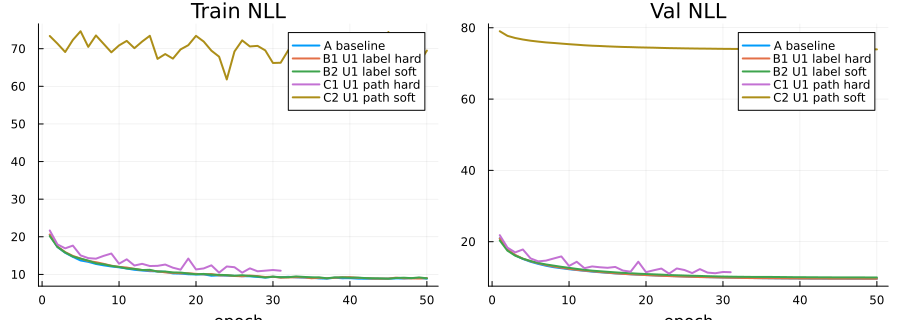

In [6]:
println("%-22s %8s %8s %8s %10s %10s" , "name", "allowed", "train%", "test%", "compat_tr", "compat_te")
for r in results
    @printf "%-22s %8.3f %7.1f%% %7.1f%% %10.3f %10.3f\n" r.name r.allowed_frac 100r.train_acc 100r.test_acc r.compat_tr r.compat_te
end

p_nll = plot(title="Train NLL", xlabel="epoch", legend=:topright)
p_val = plot(title="Val NLL", xlabel="epoch", legend=:topright)
for r in results
    plot!(p_nll, r.nll_hist, label=r.name, lw=2)
    plot!(p_val, r.val_log, label=r.name, lw=2)
end
plot(p_nll, p_val, layout=(1, 2), size=(900, 320))

## 6. Discussion prompts

- **Baseline vs U(1)**: did hard/soft conservation change test accuracy or val NLL?
- **`allowed_frac`**: fraction of tensor entries allowed by flux.  With `sites=:label_only`, path
  sites count as fully allowed so values stay near 1.0; only the label tensor is restricted.
- **`compat_tr` ≪ 1** on drift: see §8 (`:flux_exact` gives compat≈1) and §10–§11 (C3/C4 charge maps).
- **§7 Pareto**: where does soft strength sit on the accuracy–symmetry trade-off?
- **§9 audit**: SVD/Adam leak into forbidden blocks; masking should restore `residual_ok`.
- **§12 block mode**: gradient projection + compact label sectors vs Phase 0 epoch-end mask.

## 7. Pareto frontier — label-soft strength (3 seeds)

Sweep `u1_soft_strength` for `u1_label_spec` on **drift** data with seeds `{1,2,3}`.
Report mean ± std test accuracy.  Trade-off: test accuracy vs `forbid_ratio`.

A baseline  test=63.8% ± 0.7
B-soft s=0.0 seed=1 …
B-soft s=0.0 seed=2 …
B-soft s=0.0 seed=3 …
B-soft s=0.5 seed=1 …
B-soft s=0.5 seed=2 …
B-soft s=0.5 seed=3 …
B-soft s=0.7 seed=1 …
B-soft s=0.7 seed=2 …
B-soft s=0.7 seed=3 …
B-soft s=0.9 seed=1 …
B-soft s=0.9 seed=2 …
B-soft s=0.9 seed=3 …
B-soft s=0.95 seed=1 …
B-soft s=0.95 seed=2 …
B-soft s=0.95 seed=3 …
B-soft s=1.0 seed=1 …
B-soft s=1.0 seed=2 …
B-soft s=1.0 seed=3 …

strength        test%       forbid
0.00      64.9±3.3   0.0016±0.0008
0.50      57.0±1.0   0.0000±0.0000
0.70      58.1±2.2   0.0000±0.0000
0.90      56.8±7.3   0.0000±0.0000
0.95      56.9±2.8   0.0000±0.0000
1.00      53.7±5.3   0.0000±0.0000


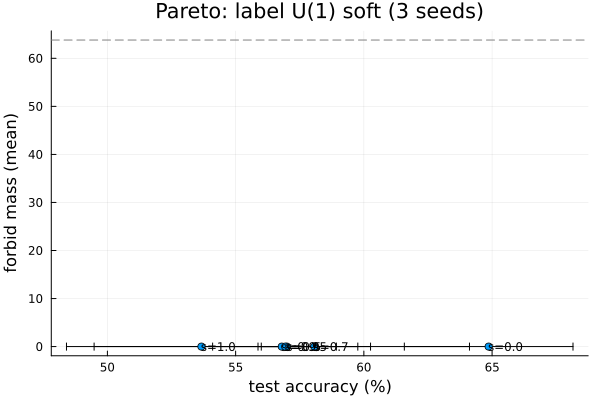

In [7]:
using Statistics

soft_grid = [0.0, 0.5, 0.7, 0.9, 0.95, 1.0]
pareto_seeds = [1, 2, 3]
spec_lbl = u1_label_spec(n_classes)

base_acc = Float64[]
for seed in pareto_seeds
    r = run_u1_experiment(; name="A baseline", spec=NoSymmetry, conservation=:none, seed=seed)
    push!(base_acc, r.test_acc)
end
println("A baseline  test=$(round(100mean(base_acc); digits=1))% ± $(round(100std(base_acc); digits=1))")

rows = Vector{NamedTuple}()
for s in soft_grid
    accs = Float64[]
    forb = Float64[]
    for seed in pareto_seeds
        println("B-soft s=$s seed=$seed …")
        r = run_u1_experiment(;
            name = "B soft s=$s",
            spec = spec_lbl,
            conservation = :soft,
            soft_strength = s,
            seed = seed,
        )
        push!(accs, r.test_acc)
        push!(forb, r.forbid_ratio)
    end
    push!(rows, (; s, test_mean=mean(accs), test_std=std(accs),
                 forbid_mean=mean(forb), forbid_std=std(forb)))
end

println("\n", @sprintf("%-8s %12s %12s", "strength", "test%", "forbid"))
for row in rows
    @printf "%-8.2f %5.1f±%-5.1f %6.4f±%-6.4f\n" row.s 100row.test_mean 100row.test_std row.forbid_mean row.forbid_std
end

xs = [100r.test_mean for r in rows]
ys = [r.forbid_mean for r in rows]
xerr = [100r.test_std for r in rows]
scatter(xs, ys, xerror=xerr, xlabel="test accuracy (%)", ylabel="forbid mass (mean)",
       title="Pareto: label U(1) soft (3 seeds)", legend=false)
for row in rows
    annotate!(100row.test_mean, row.forbid_mean, text("s=$(row.s)", 8, :left))
end
hline!([100mean(base_acc)]; label="baseline mean", ls=:dash, c=:gray)

## 8. Problem dependence — datasets

| Dataset | Labels | Expected path `compat` |
|---------|--------|------------------------|
| `:drift` | opposite drift | low (~0.1) |
| `:flux_exact` | only if `Q(x)+q_label(y)=0` | **≈ 1** |
| `:flux_nearest` | argmin \|Q+q_label\| | medium |
| `:neutral` | random | ~0.5 |

Re-run A + B2-soft + C2-soft on each.

In [8]:
function run_dataset_panel(data; seed=2)
    spec_lbl  = u1_label_spec(data.n_classes)
    spec_path = u1_path_centered_spec(data.d, data.n_classes)
    cfgs = [
        (; name="A baseline",    spec=NoSymmetry, conservation=:none, soft=0.0),
        (; name="B2 label soft", spec=spec_lbl,   conservation=:soft, soft=0.9),
        (; name="C2 path soft",  spec=spec_path,  conservation=:soft, soft=0.9),
    ]
    out = Vector{Any}(undef, length(cfgs))
    for (k, cfg) in enumerate(cfgs)
        println("  $(data.kind) / $(cfg.name)")
        out[k] = run_u1_experiment(;
            name = "$(data.kind)/$(cfg.name)",
            spec = cfg.spec,
            conservation = cfg.conservation,
            soft_strength = cfg.soft,
            data = data,
            seed = seed,
        )
    end
    return out
end

data_flux    = make_dataset(:flux_nearest; rng=MersenneTwister(43))
data_exact   = make_dataset(:flux_exact;   rng=MersenneTwister(45))
data_neutral = make_dataset(:neutral;      rng=MersenneTwister(44))

spec_path = u1_path_centered_spec(d_class, n_classes)
println("compat(path) drift=", round(sector_compatibility_rate(data_drift.xi_train, spec_path); digits=3),
        "  nearest=", round(sector_compatibility_rate(data_flux.xi_train, spec_path); digits=3),
        "  exact=", round(sector_compatibility_rate(data_exact.xi_train, spec_path); digits=3),
        "  neutral=", round(sector_compatibility_rate(data_neutral.xi_train, spec_path); digits=3))

panel = vcat(
    run_dataset_panel(data_drift;    seed=2),
    run_dataset_panel(data_exact;    seed=2),
    run_dataset_panel(data_flux;     seed=2),
    run_dataset_panel(data_neutral;  seed=2),
)

println("\n", @sprintf("%-28s %7s %10s %10s", "name", "test%", "compat", "forbid"))
for r in panel
    @printf "%-28s %6.1f%% %10.3f %10.4f\n" r.name 100r.test_acc r.compat_tr r.forbid_ratio
end

compat(path) drift=0.095  nearest=0.134  exact=1.0  neutral=0.06
  drift / A baseline
  drift / B2 label soft
  drift / C2 path soft
  flux_exact / A baseline
  flux_exact / B2 label soft
  flux_exact / C2 path soft
  flux_nearest / A baseline
  flux_nearest / B2 label soft
  flux_nearest / C2 path soft
  neutral / A baseline
  neutral / B2 label soft
  neutral / C2 path soft

name                           test%     compat     forbid
drift/A baseline               69.6%      1.000     0.0000
drift/B2 label soft            56.0%      0.486     0.0000
drift/C2 path soft             48.2%      0.095     1.0000
flux_exact/A baseline          90.8%      1.000     0.0000
flux_exact/B2 label soft       89.0%      0.581     0.0000
flux_exact/C2 path soft        40.6%      1.000     1.0000
flux_nearest/A baseline        91.6%      1.000     0.0000
flux_nearest/B2 label soft     62.6%      0.692     0.0000
flux_nearest/C2 path soft      33.0%      0.134     1.0000
neutral/A baseline            

## 9. Symmetry audit — do SVD / Adam break U(1)?

`u1_training_step_audit` runs one `update_pair!` on a copy and reports forbidden-block
mass **after SVD** vs **after masking**.  Expect:

1. `after_update_ratio > 0` — Adam+SVD leak into forbidden sectors (implementation OK).
2. `after_mask_ratio ≈ 0` and `residual_ok` — masking restores symmetry.

We probe the **label bond** (`j = Ml-1`) for B (per-bond mask) and path C (epoch-end mask).

In [9]:
function audit_spec(spec, conservation, strength; data=data_drift)
    rng = MersenneTwister(99)
    mps = init_mps_classification_u1(data.Ml, data.d, data.n_classes, D_max, spec; rng=rng)
    j = data.Ml - 1
    rep_hard = u1_training_step_audit(mps, data.xi_train, spec, j;
        η=η, D_max=D_max, ε_cut=ε_cut, conservation=:hard, strength=1.0,
        n_classes=data.n_classes, d_path=data.d, sweep=:forward)
    rep_train = u1_training_step_audit(mps, data.xi_train, spec, j;
        η=η, D_max=D_max, ε_cut=ε_cut, conservation=conservation, strength=strength,
        n_classes=data.n_classes, d_path=data.d, sweep=:forward)
    return (; spec_name=string(spec.mode), rep_hard, rep_train)
end

audits = [
    audit_spec(u1_label_spec(n_classes), :soft, 0.9),
    audit_spec(u1_path_centered_spec(d_class, n_classes), :soft, 0.9),
]

println("bond j = ", data_drift.Ml - 1)
println("\n%-12s %12s %12s %12s %8s" , "mode", "upd_ratio", "mask_ratio", "max|forbid|", "ok?")
for a in audits
    r = a.rep_hard
    @printf "%-12s %12.4f %12.2e %12.2e %8s\n" a.spec_name r.after_update_ratio r.after_mask_ratio r.after_update_max string(r.residual_ok)
end

# Post-training check on a finished B2 model
r_b2 = run_u1_experiment(; name="audit-B2", spec=u1_label_spec(n_classes),
    conservation=:soft, soft_strength=0.9, seed=3, epochs=10)
println("\nAfter 10-epoch B2 train: forbid_ratio=", r_b2.forbid_ratio,
        "  residual=", u1_symmetry_residual(r_b2.mps, u1_label_spec(n_classes);
        n_classes=n_classes, d_path=d_class, atol=1e-3))

bond j = 15

%-12s %12s %12s %12s %8smodeupd_ratiomask_ratiomax|forbid|ok?
U1_label           0.0023     0.00e+00     7.20e-01     true
U1_path_accumulating       1.0000     0.00e+00     9.99e-01     true

After 10-epoch B2 train: forbid_ratio=1.8207458759611933e-13  residual=true


## 10. Bounded data-matched charges (C3)

`u1_path_data_matched_spec` sets `q_label(c) = -clamp(round(mean Q), -1, 1)` (sectors in `{-1,0,1}`).
Compare C2 (default) vs C3 on drift, flux-exact, and flux-nearest.

In [10]:
function compare_path_specs(data; seed=4)
    spec_def = u1_path_centered_spec(data.d, data.n_classes)
    spec_dat = u1_path_data_matched_spec(data.d, data.n_classes, data.xi_train)
    println("$(data.kind): q_label default = (", spec_def.q_label(1), ",", spec_def.q_label(2), ")",
            "  C3 bounded = (", spec_dat.q_label(1), ",", spec_dat.q_label(2), ")",
            "  allowed_frac≈", round(u1_allowed_fraction(
                init_mps_classification_u1(data.Ml, data.d, data.n_classes, D_max, spec_dat;
                    rng=MersenneTwister(1)), spec_dat; n_classes=data.n_classes, d_path=data.d); digits=3))
    println("  compat default=", round(sector_compatibility_rate(data.xi_train, spec_def); digits=3),
            "  C3=", round(sector_compatibility_rate(data.xi_train, spec_dat); digits=3))
    r_def = run_u1_experiment(; name="$(data.kind)/C2 default", spec=spec_def,
        conservation=:soft, soft_strength=0.9, data=data, seed=seed)
    r_dat = run_u1_experiment(; name="$(data.kind)/C3 bounded", spec=spec_dat,
        conservation=:soft, soft_strength=0.9, data=data, seed=seed)
    return r_def, r_dat
end

c3_results = vcat(
    collect(compare_path_specs(data_drift)),
    collect(compare_path_specs(data_exact)),
    collect(compare_path_specs(data_flux)),
)

println("\n", @sprintf("%-24s %7s %10s %10s", "name", "test%", "compat", "forbid"))
for r in c3_results
    @printf "%-24s %6.1f%% %10.3f %10.4f\n" r.name 100r.test_acc r.compat_tr r.forbid_ratio
end

drift: q_label default = (0,1)  C3 bounded = (-1,1)  allowed_frac≈0.999
  compat default=0.095  C3=0.058
flux_exact: q_label default = (0,1)  C3 bounded = (0,1)  allowed_frac≈0.999
  compat default=1.0  C3=1.0
flux_nearest: q_label default = (0,1)  C3 bounded = (-1,1)  allowed_frac≈0.999
  compat default=0.134  C3=0.089

name                       test%     compat     forbid
drift/C2 default           48.2%      0.095     1.0000
drift/C3 bounded           48.2%      0.058     1.0000
flux_exact/C2 default      40.6%      1.000     1.0000
flux_exact/C3 bounded      40.6%      1.000     1.0000
flux_nearest/C2 default    33.0%      0.134     1.0000
flux_nearest/C3 bounded    33.0%      0.089     1.0000


## 11. Empirical label-bond range (C4)

`u1_path_empirical_spec` adds `label_left_range` from training-path charge quantiles (5–95%),
so more bond indices align with observed `Q(x)`.  Compare C2 / C3 / C4 on drift and flux-exact.

In [11]:
function compare_path_c4(data; seed=5)
    spec_c2 = u1_path_centered_spec(data.d, data.n_classes)
    spec_c3 = u1_path_data_matched_spec(data.d, data.n_classes, data.xi_train)
    spec_c4 = u1_path_empirical_spec(data.d, data.n_classes, data.xi_train)
    ql, qr = spec_c4.label_left_range
    println("$(data.kind): C4 label_left_range = ($ql, $qr)")
    for (tag, spec) in (("C2", spec_c2), ("C3", spec_c3), ("C4", spec_c4))
        m = init_mps_classification_u1(data.Ml, data.d, data.n_classes, D_max, spec; rng=MersenneTwister(1))
        af = u1_allowed_fraction(m, spec; n_classes=data.n_classes, d_path=data.d)
        cp = sector_compatibility_rate(data.xi_train, spec)
        println("  $tag  allowed_frac=$(round(af; digits=3))  compat=$(round(cp; digits=3))")
    end
    out = Any[]
    for (tag, spec) in (("C2 default", spec_c2), ("C3 bounded", spec_c3), ("C4 empirical", spec_c4))
        push!(out, run_u1_experiment(; name="$(data.kind)/$tag", spec=spec,
            conservation=:soft, soft_strength=0.9, data=data, seed=seed))
    end
    return out
end

c4_results = vcat(compare_path_c4(data_drift), compare_path_c4(data_exact))

println("\n", @sprintf("%-26s %7s %10s %10s", "name", "test%", "compat", "forbid"))
for r in c4_results
    @printf "%-26s %6.1f%% %10.3f %10.4f\n" r.name 100r.test_acc r.compat_tr r.forbid_ratio
end

drift: C4 label_left_range = (-16, 12)
  C2  allowed_frac=0.999  compat=0.095
  C3  allowed_frac=0.999  compat=0.058
  C4  allowed_frac=0.999  compat=0.058
flux_exact: C4 label_left_range = (-1, 0)
  C2  allowed_frac=0.999  compat=1.0
  C3  allowed_frac=0.999  compat=1.0
  C4  allowed_frac=1.0  compat=1.0

name                         test%     compat     forbid
drift/C2 default             48.2%      0.095     1.0000
drift/C3 bounded             48.2%      0.058     1.0000
drift/C4 empirical           62.4%      0.058     1.0000
flux_exact/C2 default        40.6%      1.000     1.0000
flux_exact/C3 bounded        40.6%      1.000     1.0000
flux_exact/C4 empirical      86.6%      1.000     0.0000


## 12. Phase 1 — block-sparse label (`u1_block_mode`)

Compare **C4 empirical** on drift and `:flux_exact`:

| Variant | Init | Training | `D_max` |
|---------|------|----------|---------|
| Phase 0 soft | `init_mps_classification_u1` | epoch-end `apply_u1_conservation!` | 32 |
| Phase 1 block | `init_mps_classification_u1_block` | merged-bond gradient projection + label projection | **64** (§13 capacity) |

`block_stats.compact_params / dense_params` is the label-site storage ratio (allowed blocks only).

In [12]:
function run_block_panel(data; seed=6, epochs=n_epochs)
    spec_c4 = u1_path_empirical_spec(data.d, data.n_classes, data.xi_train)
    out = Any[]
    push!(out, run_u1_experiment(; name="$(data.kind)/A baseline",
        spec=NoSymmetry, conservation=:none, data=data, seed=seed, epochs=epochs))
    push!(out, run_u1_experiment(; name="$(data.kind)/C4 Phase0 soft",
        spec=spec_c4, conservation=:soft, soft_strength=0.9, data=data, seed=seed, epochs=epochs))
    push!(out, run_u1_experiment(; name="$(data.kind)/C4 Phase1 block",
        spec=spec_c4, conservation=:hard, data=data, seed=seed, epochs=epochs,
        u1_block_mode=true, D_max_train=D_max_phase1))
    return out
end

# Self-contained datasets (or reuse `data_exact` from §8)
rng_block = MersenneTwister(46)
data_exact_block = make_dataset(:flux_exact; rng=rng_block)

block_panel = vcat(
    run_block_panel(data_drift; seed=6),
    run_block_panel(data_exact_block; seed=7),
)

println(@sprintf("%-28s %7s %10s %10s %10s", "name", "test%", "compat", "forbid", "compact"))
for r in block_panel
    compact = r.block_stats === nothing ? 1.0 :
        r.block_stats.compact_params / r.block_stats.dense_params
    @printf "%-28s %6.1f%% %10.3f %10.4f %10.3f\n" r.name 100r.test_acc r.compat_tr r.forbid_ratio compact
end

# Symmetry audit: one bond update, Phase 1 should restore symmetry via label projection
spec_c4_drift = u1_path_empirical_spec(d_class, n_classes, data_drift.xi_train)
mps_audit, layout_audit, _ = init_mps_classification_u1_block(
    Ml_class, d_class, n_classes, D_max, spec_c4_drift; rng=MersenneTwister(99))
rep_blk = u1_block_training_step_audit(
    mps_audit, data_drift.xi_train, spec_c4_drift, layout_audit, Ml_class - 1;
    η=η, D_max=D_max, ε_cut=ε_cut, n_classes=n_classes, d_path=d_class, sweep=:forward)
println("\nBlock audit (C4 drift, bond ", Ml_class - 1, "): upd=",
    round(rep_blk.after_update_ratio; digits=4),
    "  after_project=", round(rep_blk.after_mask_ratio; sigdigits=3),
    "  ok=", rep_blk.residual_ok)

name                           test%     compat     forbid    compact
drift/A baseline               68.2%      1.000     0.0000      1.000
drift/C4 Phase0 soft           60.4%      0.058     1.0000      1.000
drift/C4 Phase1 block          51.8%      0.058     0.0000      0.500
flux_exact/A baseline          84.0%      1.000     0.0000      1.000
flux_exact/C4 Phase0 soft      85.0%      1.000     0.0000      1.000
flux_exact/C4 Phase1 block     85.0%      1.000     0.0000      0.500

Block audit (C4 drift, bond 15): upd=0.0  after_project=0.0  ok=true


## 13. Phase 1 ablations

Follow-up to §12. Re-run **§1** (imports + `ensure_train_mps_epoch_callback!`) and **§2** after pulling MPSFast changes.

| § | Question |
|---|----------|
| 13.1 | **Fair compare** — C4 Phase 0 soft vs hard vs Phase 1 block (`D_max_phase1`) on `:flux_exact` |
| 13.2 | **Capacity** — Phase 1 with `D_max ∈ {32, 64, 96}` |
| 13.3 | **Init** — sector-aligned block init vs dense `init_mps_classification_u1`; widen `label_left_range` |
| 13.4 | **Traces** — per-epoch test accuracy & `forbid_ratio` via `train_mps!` `epoch_callback` |

Uses `data_exact_block` from §12 when available (same flux-exact set as the block panel).

In [13]:
# §13 shared setup (prefer §12 `data_exact_block` for apples-to-apples with §12)
data_abl = @isdefined(data_exact_block) ? data_exact_block :
    (@isdefined(data_exact) ? data_exact :
        make_dataset(:flux_exact; rng=MersenneTwister(45)))
spec_c4_abl = u1_path_empirical_spec(data_abl.d, data_abl.n_classes, data_abl.xi_train)
seed_abl = 7

function run_c4_abl(; name, data=data_abl, spec=spec_c4_abl, kwargs...)
    run_u1_experiment(; name=name, spec=spec, data=data, seed=seed_abl, kwargs...)
end

# §13.1 — fair comparison on flux_exact (P1 at D_max_phase1 like §12)
fair_panel = [
    run_c4_abl(; name="flux_exact/C4 P0 soft",
        conservation=:soft, soft_strength=0.9),
    run_c4_abl(; name="flux_exact/C4 P0 hard",
        conservation=:hard),
    run_c4_abl(; name="flux_exact/C4 P1 block",
        conservation=:hard, u1_block_mode=true, D_max_train=D_max_phase1),
    run_c4_abl(; name="flux_exact/C4 P1 dense-init",
        conservation=:hard, u1_block_mode=true, block_sector_align=false,
        D_max_train=D_max_phase1),
]

println(@sprintf("%-32s %7s %10s %10s %10s %4s", "name", "test%", "compat", "forbid", "compact", "D"))
for r in fair_panel
    print_ablation_row(r)
end

name                               test%     compat     forbid    compact    D
flux_exact/C4 P0 soft              84.2%      1.000     0.0000      1.000   32
flux_exact/C4 P0 hard              82.4%      1.000     0.0000      1.000   32
flux_exact/C4 P1 block             79.8%      1.000     0.0000      0.500   64
flux_exact/C4 P1 dense-init        81.4%      1.000     0.0000      0.500   64


In [14]:
# §13.2 — capacity sweep (Phase 1 block)
capacity_panel = map(D -> run_c4_abl(;
    name = "flux_exact/P1 D_max=$D",
    conservation = :hard,
    u1_block_mode = true,
    D_max_train = D,
), [32, 64, 96])

println(@sprintf("%-32s %7s %10s %10s %10s %4s", "name", "test%", "compat", "forbid", "compact", "D"))
for r in capacity_panel
    print_ablation_row(r)
end

name                               test%     compat     forbid    compact    D
flux_exact/P1 D_max=32             61.2%      1.000     0.0000      0.500   64
flux_exact/P1 D_max=64             79.6%      1.000     0.0000      0.500   64
flux_exact/P1 D_max=96             61.2%      1.000     0.0000      0.500   96


In [15]:
# §13.3 — init ablation + widened empirical bond range
spec_c4_wide = widen_c4_spec(spec_c4_abl; pad=3)
spec_c4_quant = u1_path_empirical_spec(
    data_abl.d, data_abl.n_classes, data_abl.xi_train; q_lo=0.0, q_hi=1.0)

println("label_left_range  C4=$(spec_c4_abl.label_left_range)  wide=$(spec_c4_wide.label_left_range)  q01=$(spec_c4_quant.label_left_range)")

init_panel = [
    run_c4_abl(; name="flux_exact/P1 sector-align",
        conservation=:hard, u1_block_mode=true, block_sector_align=true),
    run_c4_abl(; name="flux_exact/P1 dense-init",
        conservation=:hard, u1_block_mode=true, block_sector_align=false),
    run_c4_abl(; name="flux_exact/P1 wide-range",
        conservation=:hard, u1_block_mode=true, spec=spec_c4_wide),
    run_c4_abl(; name="flux_exact/P1 q0-100%",
        conservation=:hard, u1_block_mode=true, spec=spec_c4_quant),
]

println(@sprintf("\n%-32s %7s %10s %10s %10s %4s", "name", "test%", "compat", "forbid", "compact", "D"))
for r in init_panel
    print_ablation_row(r)
end

label_left_range  C4=(-1, 0)  wide=(-4, 3)  q01=(-1, 0)

name                               test%     compat     forbid    compact    D
flux_exact/P1 sector-align         61.2%      1.000     0.0000      0.500   64
flux_exact/P1 dense-init           80.0%      1.000     0.0000      0.500   64
flux_exact/P1 wide-range           85.2%      1.000     0.0000      0.500   64
flux_exact/P1 q0-100%              83.2%      1.000     0.0000      0.500   64


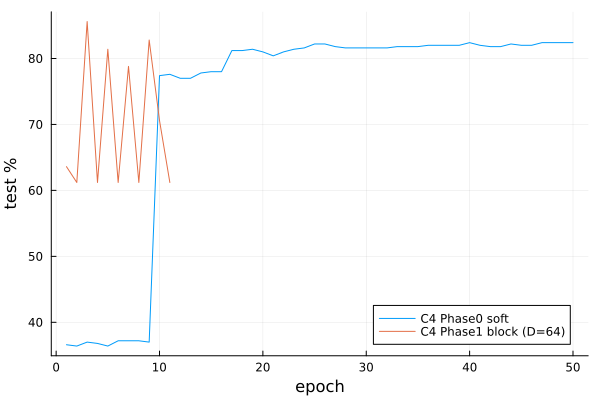

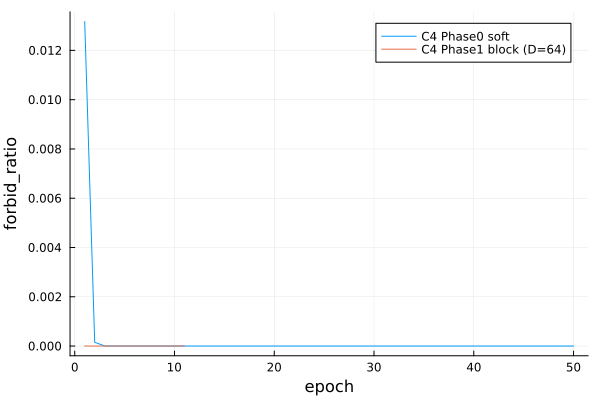

final test%  P0=82.4  P1=61.2  (epochs logged: 50)


In [16]:
# §13.4 — per-epoch traces (single `train_mps!` run; Adam + LR schedule preserved)
ensure_train_mps_epoch_callback!()
epochs_trace = n_epochs

r_trace_p0 = run_c4_abl(; name="trace/P0 soft", conservation=:soft, soft_strength=0.9,
    epochs=epochs_trace, trace_epochs=true)
r_trace_p1 = run_c4_abl(; name="trace/P1 block", conservation=:hard, u1_block_mode=true,
    epochs=epochs_trace, trace_epochs=true, D_max_train=D_max_phase1)

n_trace = length(r_trace_p0.test_trace)
println("final test%  P0=$(round(100r_trace_p0.test_acc; digits=1))  ",
    "P1=$(round(100r_trace_p1.test_acc; digits=1))  (epochs logged: $n_trace)")

p1 = plot(1:n_trace, 100 .* r_trace_p0.test_trace;
    label="C4 Phase0 soft", xlabel="epoch", ylabel="test %", legend=:bottomright)
plot!(p1, 1:length(r_trace_p1.test_trace), 100 .* r_trace_p1.test_trace;
    label="C4 Phase1 block (D=64)")
display(p1)

p2 = plot(1:n_trace, r_trace_p0.forbid_trace;
    label="C4 Phase0 soft", xlabel="epoch", ylabel="forbid_ratio", legend=:topright)
plot!(p2, 1:length(r_trace_p1.forbid_trace), r_trace_p1.forbid_trace;
    label="C4 Phase1 block (D=64)")
display(p2)

## 14. Phase 1 polish + Phase 2 scaffold

| § | Question |
|---|----------|
| 14.1 | **Multi-seed** — P0 soft vs P1 block (`:hard`) on `:flux_exact` (5 seeds) |
| 14.2 | **Soft→hard** — P1 with `:soft_then_hard` vs `:hard` |
| 14.3 | **Compat gate** — auto-disable U(1) on drift, keep on flux_exact |
| 14.4 | **Phase 2 smoke** — `u1_path_block_mode=true` (experimental) |

Re-run **§1** (imports + `refresh_mpsfast_training!`) and **§2** after pulling library changes.

In [4]:
# §14 shared
data_polish = @isdefined(data_exact_block) ? data_exact_block :
    make_dataset(:flux_exact; rng=MersenneTwister(48))
spec_c4_polish = u1_path_empirical_spec(data_polish.d, data_polish.n_classes, data_polish.xi_train)
seeds_polish = 3:7

function run_polish(; name, kwargs...)
    run_u1_experiment(; name=name, spec=spec_c4_polish, data=data_polish, kwargs...)
end

function seed_panel(configs, seeds=seeds_polish)
    out = Any[]
    for (cfg, seed) in Iterators.product(configs, seeds)
        push!(out, run_polish(; name="$(cfg.label)/seed=$seed", seed=seed, cfg.kwargs...))
    end
    return out
end

# unique(f, itr) ignores f when itr is Vector{Any}; use a comprehension instead.
_seed_config(name::AbstractString) = split(name, "/seed="; limit=2)[1]

function summarize_seeds(results)
    labels = sort(unique(String, (_seed_config(r.name) for r in results)))
    println(@sprintf("%-22s %7s %7s %7s %7s", "config", "mean%", "std%", "min%", "max%"))
    for lab in labels
        xs = [100 * r.test_acc for r in results if _seed_config(r.name) == lab]
        μ, σ = mean(xs), std(xs)
        @printf "%-22s %6.1f%% %6.1f%% %6.1f%% %6.1f%%\n" lab μ σ minimum(xs) maximum(xs)
    end
end


summarize_seeds (generic function with 1 method)

In [5]:
# §14.1 — multi-seed stability (P1 block uses :hard; soft→hard breaks block — see §14.2)
configs_seed = [
    (; label="flux/P0 soft", kwargs=(; conservation=:soft, soft_strength=0.9)),
    (; label="flux/P1 block", kwargs=(; conservation=:hard, u1_block_mode=true)),
]
seed_results = seed_panel(configs_seed)
summarize_seeds(seed_results)


config                   mean%    std%    min%    max%
flux/P0 soft             88.0%    1.8%   86.4%   91.0%
flux/P1 block            68.7%   10.6%   61.0%   80.8%


In [6]:
# §14.2 — soft→hard vs hard (single seed, matched D=64)
schedule_panel = [
    run_polish(; name="flux/P1 hard", seed=7, conservation=:hard, u1_block_mode=true),
    run_polish(; name="flux/P1 soft→hard", seed=7, conservation=:soft_then_hard,
        u1_block_mode=true, u1_soft_epochs_kw=10, soft_strength=0.5),
    run_polish(; name="flux/P0 soft→hard", seed=7, conservation=:soft_then_hard,
        soft_strength=0.9),
]
println(@sprintf("%-24s %7s %10s %10s", "name", "test%", "compat", "forbid"))
for r in schedule_panel
    @printf "%-24s %6.1f%% %10.3f %10.4f\n" r.name (100 * r.test_acc) r.compat_tr r.forbid_ratio
end


name                       test%     compat     forbid
flux/P1 hard               83.6%      1.000     0.0000
flux/P1 soft→hard           7.8%      1.000     0.0005
flux/P0 soft→hard          88.2%      1.000     0.0000


In [7]:
# §14.3 — compatibility gate (per-dataset C4 spec)
spec_c4_drift_gate = u1_path_empirical_spec(
    data_drift.d, data_drift.n_classes, data_drift.xi_train)
println("drift compat=", round(sector_compatibility_rate(data_drift.xi_train, spec_c4_drift_gate); digits=3),
    "  flux compat=", round(sector_compatibility_rate(data_polish.xi_train, spec_c4_polish); digits=3))

gate_rows = [
    run_u1_experiment(; name="drift/gated C4", spec=spec_c4_drift_gate, data=data_drift,
        seed=6, conservation=:hard, u1_block_mode=true, compat_gate=true),
    run_u1_experiment(; name="flux/gated C4", spec=spec_c4_polish, data=data_polish,
        seed=7, conservation=:hard, u1_block_mode=true, compat_gate=true),
]
compat_drift = sector_compatibility_rate(data_drift.xi_train, spec_c4_drift_gate)
compat_flux  = sector_compatibility_rate(data_polish.xi_train, spec_c4_polish)
println(@sprintf("\n%-20s %7s %10s %s", "name", "test%", "compat", "plan"))
for r in gate_rows
    pre_compat = startswith(r.name, "drift") ? compat_drift : compat_flux
    @printf "%-20s %6.1f%% %10.3f  %s\n" r.name (100 * r.test_acc) pre_compat r.plan_reason
end


drift compat=0.058  flux compat=1.0

name                   test%     compat plan
drift/gated C4         66.2%      0.058  compat=0.058 < threshold=0.5
flux/gated C4          61.0%      1.000  P1 block D=64


In [8]:
# §14.4 — Phase 2 path-block smoke (experimental; may underperform P1)
r_p2 = run_polish(; name="flux/P2 path-block", seed=7,
    conservation=:soft_then_hard, u1_path_block_mode=true, u1_block_mode=false)
chain = build_u1_chain_layout(r_p2.spec, r_p2.mps, data_polish.n_classes, data_polish.d)
fracs = [u1_path_bond_allowed_fraction(chain, j, data_polish.Ml,
    size(r_p2.mps[j],1), size(r_p2.mps[j],2), size(r_p2.mps[j+1],2), size(r_p2.mps[j+1],3))
    for j in 1:(data_polish.Ml-1)]
println("P2 path-block  test=", round(100 * r_p2.test_acc; digits=1), "%  forbid=", round(r_p2.forbid_ratio; digits=4))
println("bond allowed_frac  min=", round(minimum(fracs); digits=3),
    "  mean=", round(mean(fracs); digits=3), "  (lower ⇒ sparser chain)")


P2 path-block  test=37.2%  forbid=0.9481
bond allowed_frac  min=0.0  mean=0.021  (lower ⇒ sparser chain)
